In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
import json

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
stage = "river"

### Reading and compacting dfs

In [3]:
compact = False

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith('.csv'):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

dfs = [] # Clear memory
raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage,origin
0,0.001377,0.000228,0.001744,0.000486,0.000538,0.000434,0.000950,0.001289,0.000914,0.001696,...,469,40,495,True,True,True,964,1487,river,after_range_fix
1,0.001339,0.000039,0.000013,0.000504,0.000867,0.001299,0.001545,0.000667,0.001549,0.000661,...,119,13,121,True,True,True,240,2003,river,after_range_fix
2,0.000000,0.001377,0.000651,0.000391,0.001705,0.000569,0.000410,0.001504,0.000090,0.000198,...,370,117,377,True,True,True,747,2001,river,after_range_fix
3,0.001162,0.001362,0.000000,0.001594,0.001635,0.001112,0.000135,0.001304,0.000315,0.001661,...,305,325,630,True,True,True,935,2326,river,after_range_fix
4,0.000171,0.000427,0.001027,0.000752,0.000495,0.000646,0.001213,0.000560,0.001425,0.001687,...,180,28,208,True,False,True,388,1088,river,after_range_fix
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11007,0.001510,0.001131,0.001499,0.000144,0.000465,0.000000,0.000973,0.001789,0.001542,0.001787,...,103,45,148,True,False,True,251,1333,river,after_range_fix
11008,0.000990,0.001654,0.000506,0.000000,0.000199,0.001468,0.001385,0.001262,0.001167,0.000688,...,409,92,501,True,False,True,910,1907,river,after_range_fix
11009,0.000293,0.000851,0.001572,0.001028,0.000965,0.001796,0.000691,0.001638,0.001164,0.000123,...,143,167,310,True,True,True,453,1442,river,after_range_fix
11010,0.001447,0.000098,0.000460,0.000000,0.000387,0.000091,0.001042,0.000552,0.001136,0.000000,...,439,118,557,True,False,True,996,2194,river,after_range_fix


In [5]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage", "origin"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.001377,0.000228,0.001744,0.000486,0.000538,0.000434,0.000950,0.001289,0.000914,0.001696,...,0.0,14,469,40,495,True,True,True,964,1487
1,0.001339,0.000039,0.000013,0.000504,0.000867,0.001299,0.001545,0.000667,0.001549,0.000661,...,0.0,11,119,13,121,True,True,True,240,2003
2,0.000000,0.001377,0.000651,0.000391,0.001705,0.000569,0.000410,0.001504,0.000090,0.000198,...,0.0,110,370,117,377,True,True,True,747,2001
3,0.001162,0.001362,0.000000,0.001594,0.001635,0.001112,0.000135,0.001304,0.000315,0.001661,...,0.0,0,305,325,630,True,True,True,935,2326
4,0.000171,0.000427,0.001027,0.000752,0.000495,0.000646,0.001213,0.000560,0.001425,0.001687,...,0.0,0,180,28,208,True,False,True,388,1088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11007,0.001510,0.001131,0.001499,0.000144,0.000465,0.000000,0.000973,0.001789,0.001542,0.001787,...,1.0,0,103,45,148,True,False,True,251,1333
11008,0.000990,0.001654,0.000506,0.000000,0.000199,0.001468,0.001385,0.001262,0.001167,0.000688,...,0.0,0,409,92,501,True,False,True,910,1907
11009,0.000293,0.000851,0.001572,0.001028,0.000965,0.001796,0.000691,0.001638,0.001164,0.000123,...,0.0,0,143,167,310,True,True,True,453,1442
11010,0.001447,0.000098,0.000460,0.000000,0.000387,0.000091,0.001042,0.000552,0.001136,0.000000,...,0.0,0,439,118,557,True,False,True,996,2194


In [6]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [7]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.009415,0.315400,0.026900,0.332885,0.648285
1,0.005492,0.059411,0.006490,0.060409,0.119820
2,0.054973,0.184908,0.058471,0.188406,0.373313
3,0.000000,0.131126,0.139725,0.270851,0.401978
4,0.000000,0.165441,0.025735,0.191176,0.356618
...,...,...,...,...,...
11007,0.000000,0.077269,0.033758,0.111028,0.188297
11008,0.000000,0.214473,0.048243,0.262716,0.477189
11009,0.000000,0.099168,0.115811,0.214979,0.314147
11010,0.000000,0.200091,0.053783,0.253874,0.453965


In [8]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713419 0.000770533625710626
Mean and sd of range features after scaling:
6.621692864969332e-16 1.0000000000000007


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,0.808807,-0.683163,1.284474,-0.347885,-0.280133,-0.415916,0.254466,0.693660,0.207728,1.221888,...,1.345735,-0.103256,-0.978734,1.342759,-0.812552,-0.978734,1.321104,-0.978734,0.013648,-0.978734
1,0.759474,-0.927745,-0.962182,-0.325154,0.146226,0.707641,1.026122,-0.112469,1.031531,-0.120647,...,0.326146,0.900967,-0.672221,-0.326555,-0.879847,-0.923954,-0.469735,-0.063794,0.250690,-0.029686
2,-0.978734,0.808234,-0.134238,-0.471587,1.233494,-0.240483,-0.446733,0.973715,-0.862509,-0.721972,...,0.091379,-0.222845,1.222998,1.246044,0.456993,0.341179,0.285648,0.298775,0.275981,-0.005157
3,0.529562,0.789331,-0.978734,1.089893,1.143142,0.464118,-0.803939,0.713403,-0.570463,1.177458,...,-0.111220,1.206091,0.739331,0.029364,1.149535,0.515228,-0.359779,0.643160,0.532345,-0.273787
4,-0.756422,-0.424277,0.353915,-0.003114,-0.336449,-0.140036,0.595086,-0.252335,0.870243,1.210988,...,0.051786,0.303206,-0.978734,0.203872,1.454295,-0.978734,0.933963,-0.978734,0.648580,-0.978734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11007,0.980306,0.488902,0.966247,-0.792300,-0.374766,-0.978734,0.283951,1.342878,1.022514,1.340267,...,-0.978734,-0.978734,-0.978734,-0.978734,-0.772334,0.313961,-0.978734,0.701640,-0.978734,-0.978734
11008,0.306218,1.168387,-0.322380,-0.978734,-0.720093,0.926029,0.819123,0.658989,0.535985,-0.085302,...,0.499895,-0.730298,0.874613,0.787726,-0.509006,-0.439789,-0.624876,0.813722,1.397699,-0.950587
11009,-0.598662,0.126061,1.061530,0.355569,0.273150,1.351975,-0.082272,1.147302,0.532042,-0.819348,...,-0.126812,0.418125,1.036868,0.453398,1.272619,0.399437,1.470578,0.380557,-0.201863,-0.082705
11010,0.898632,-0.851451,-0.381956,-0.978734,-0.477014,-0.860664,0.373958,-0.262912,0.495605,-0.978734,...,1.079325,-0.333009,1.250243,-0.680236,1.256890,1.135238,1.180417,0.998058,0.302855,0.778966


In [9]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,0,1
...,...,...,...
11007,1,0,1
11008,1,0,1
11009,1,1,1
11010,1,0,1


In [10]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.808807,-0.683163,1.284474,-0.347885,-0.280133,-0.415916,0.254466,0.693660,0.207728,1.221888,...,1.0,0.0,0.009415,0.315400,0.026900,0.332885,1,1,1,0.648285
1,0.759474,-0.927745,-0.962182,-0.325154,0.146226,0.707641,1.026122,-0.112469,1.031531,-0.120647,...,0.0,0.0,0.005492,0.059411,0.006490,0.060409,1,1,1,0.119820
2,-0.978734,0.808234,-0.134238,-0.471587,1.233494,-0.240483,-0.446733,0.973715,-0.862509,-0.721972,...,0.0,0.0,0.054973,0.184908,0.058471,0.188406,1,1,1,0.373313
3,0.529562,0.789331,-0.978734,1.089893,1.143142,0.464118,-0.803939,0.713403,-0.570463,1.177458,...,0.0,0.0,0.000000,0.131126,0.139725,0.270851,1,1,1,0.401978
4,-0.756422,-0.424277,0.353915,-0.003114,-0.336449,-0.140036,0.595086,-0.252335,0.870243,1.210988,...,1.0,0.0,0.000000,0.165441,0.025735,0.191176,1,0,1,0.356618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11007,0.980306,0.488902,0.966247,-0.792300,-0.374766,-0.978734,0.283951,1.342878,1.022514,1.340267,...,0.0,1.0,0.000000,0.077269,0.033758,0.111028,1,0,1,0.188297
11008,0.306218,1.168387,-0.322380,-0.978734,-0.720093,0.926029,0.819123,0.658989,0.535985,-0.085302,...,0.0,0.0,0.000000,0.214473,0.048243,0.262716,1,0,1,0.477189
11009,-0.598662,0.126061,1.061530,0.355569,0.273150,1.351975,-0.082272,1.147302,0.532042,-0.819348,...,0.0,0.0,0.000000,0.099168,0.115811,0.214979,1,1,1,0.314147
11010,0.898632,-0.851451,-0.381956,-0.978734,-0.477014,-0.860664,0.373958,-0.262912,0.495605,-0.978734,...,0.0,0.0,0.000000,0.200091,0.053783,0.253874,1,0,1,0.453965


### Data validation

In [11]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0029417344151045095
SD of target variable: 0.10793104455550707
Min of target variable: -0.8818916936396344
Max of target variable: 0.8609302298636172


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,-0.077556,-0.080049,-0.077250,-0.078885,-0.079717,-0.080043,-0.080148,-0.069122,-0.080732,-0.081468,...,-0.151702,-0.153874,0.000000,-0.307984,-0.260348,0.000000,-0.255468,0.000000,-0.258346,0.000000
1,-0.047246,-0.001110,-0.047375,-0.003149,-0.003528,-0.048851,-0.005460,-0.008500,-0.010667,-0.012335,...,0.046367,0.029447,-0.043047,0.011616,0.026398,-0.044054,0.008799,-0.044276,0.006200,-0.045863
2,0.000000,0.253861,0.242251,0.222481,0.191331,-0.078510,0.147640,-0.107899,0.101188,-0.144183,...,-0.119029,-0.174869,-0.119712,-0.122051,-0.145311,0.022685,-0.033726,-0.147319,-0.148063,-0.039933
3,0.012352,-0.069887,0.000000,-0.240511,0.365342,0.353537,0.312100,-0.123006,0.261475,0.197304,...,-0.140460,-0.146467,-0.230243,-0.150356,0.146479,-0.182952,0.062879,-0.190391,0.049666,-0.195902
4,-0.020892,-0.021470,-0.022089,-0.022931,-0.023262,-0.152582,-0.020198,-0.153159,-0.045136,-0.048481,...,-0.088238,-0.091190,0.000000,-0.167217,-0.172417,0.000000,-0.144911,0.000000,-0.147973,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11007,0.034662,0.035098,0.035030,-0.045375,0.023018,0.000000,0.003546,-0.001809,-0.067444,0.032335,...,0.000000,0.000000,0.000000,0.000000,-0.067271,-0.067337,0.000000,0.027639,0.000000,0.000000
11008,0.352641,-0.065987,0.342945,0.000000,0.313821,0.271560,0.216663,-0.121832,0.147831,-0.165261,...,-0.120774,-0.137266,-0.136684,-0.141026,-0.175132,0.029895,-0.057566,-0.180965,-0.183687,-0.067186
11009,0.245406,0.245795,0.246092,0.246567,-0.064153,0.170195,-0.177460,0.111105,0.047294,-0.108483,...,-0.182078,-0.110892,-0.147015,-0.031312,-0.110736,-0.146738,-0.032935,-0.124933,-0.123286,-0.157056
11010,-0.062400,0.345607,0.333520,0.000000,-0.151615,0.317041,0.277341,0.225766,0.165070,0.000000,...,0.121217,-0.212846,0.047962,-0.047398,-0.210440,0.036906,-0.058077,-0.218041,-0.219216,-0.071381


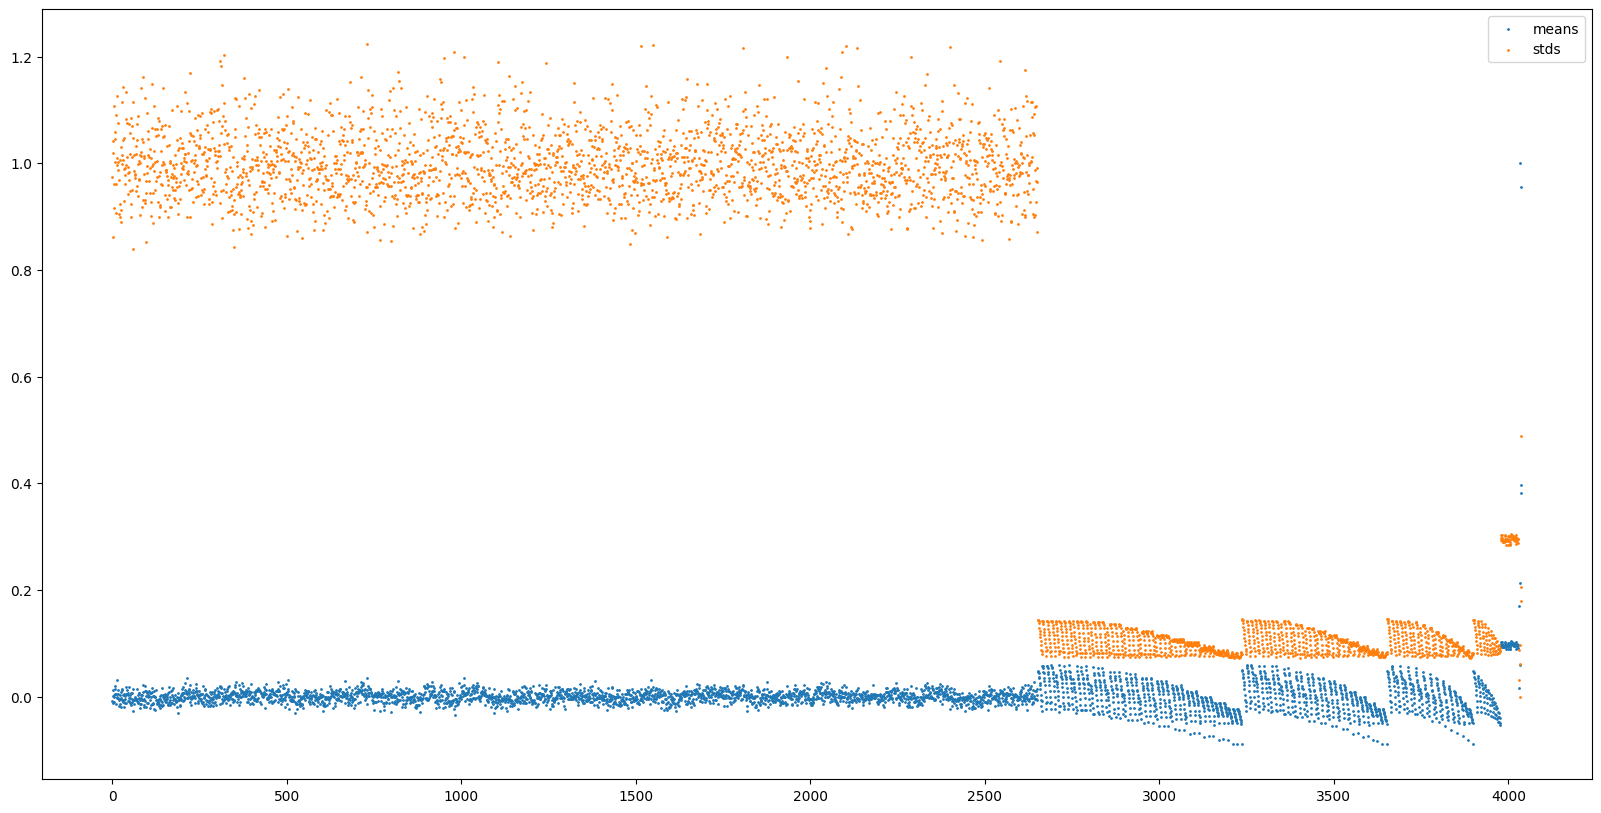

In [12]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means", s=1)
plt.scatter(range(df.std().size), df.std(), label="stds", s=1)
plt.legend()
plt.show()

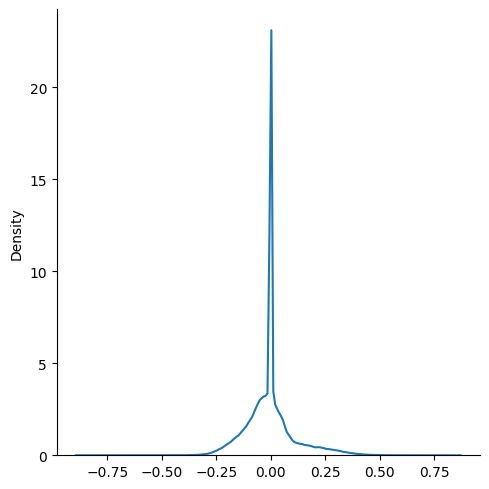

In [13]:
# Plot distribution of target values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


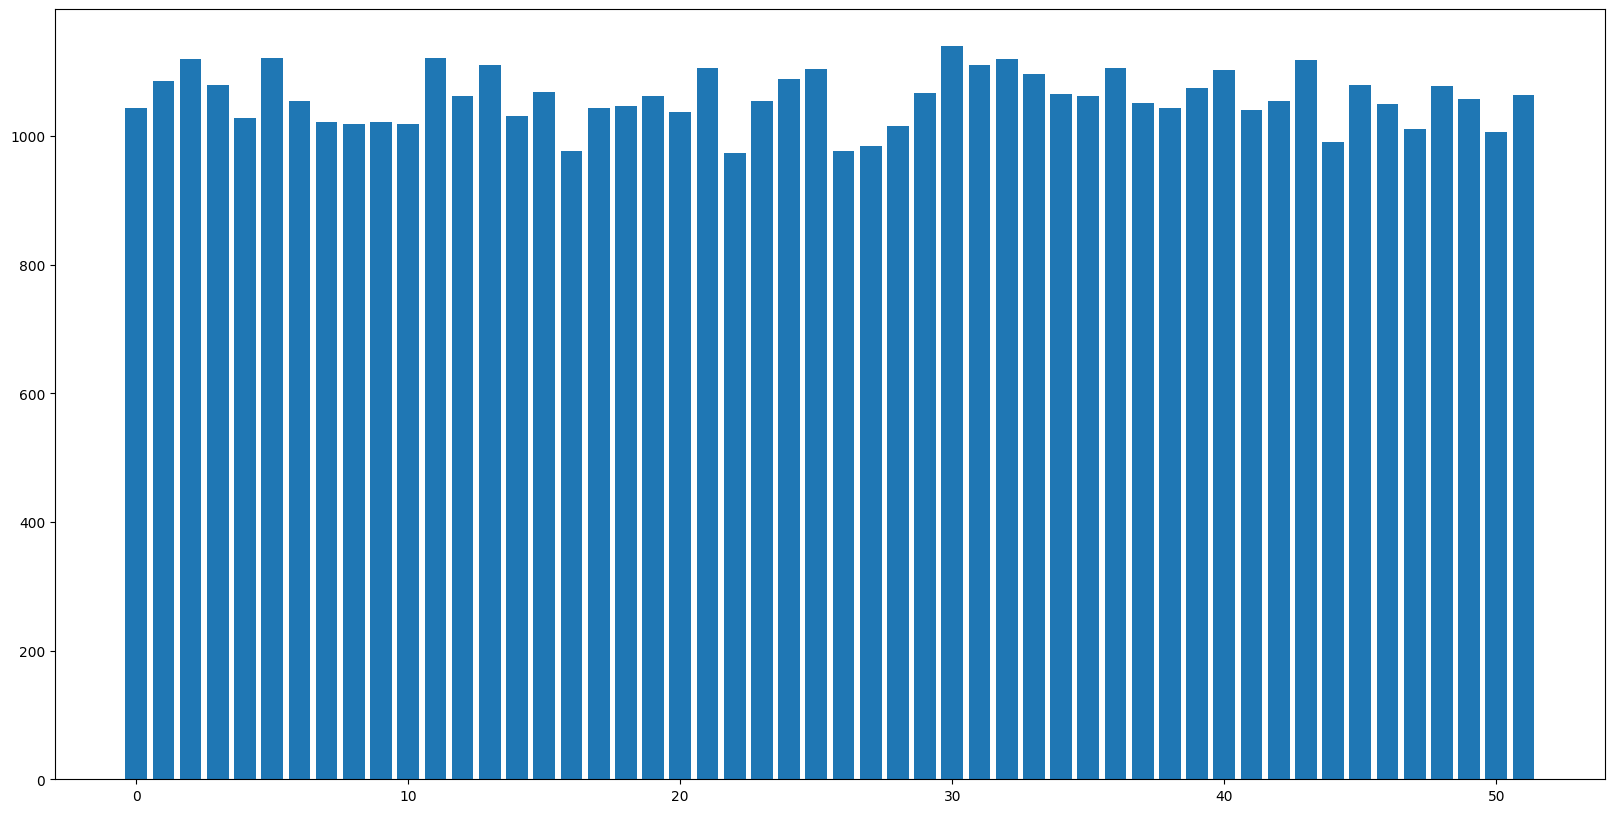

In [14]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

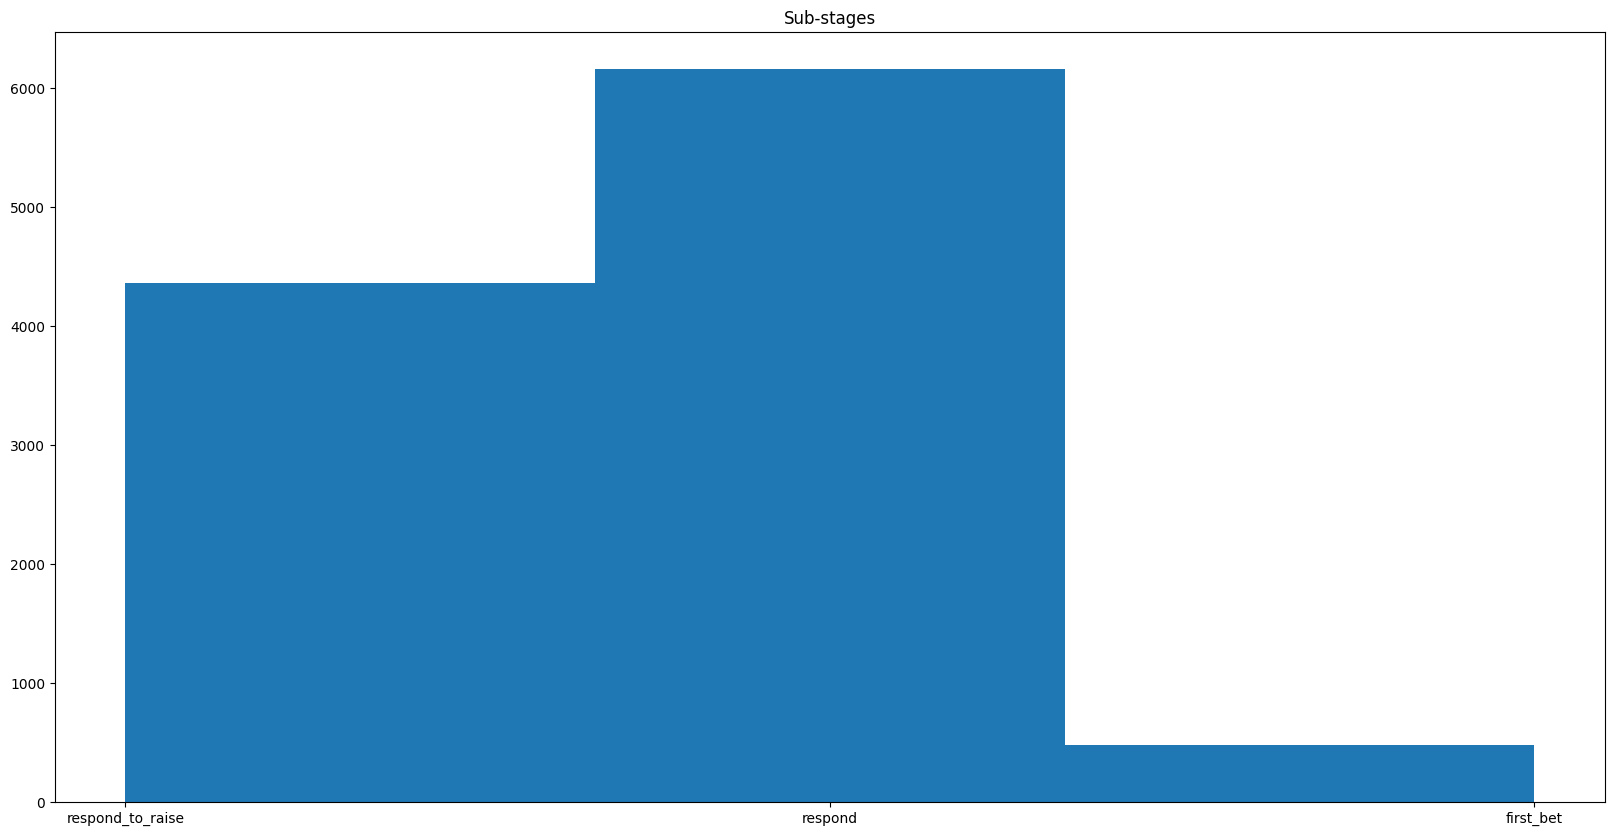

In [15]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [16]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(11012, 2712) (11012, 1326)


### Structure for Neural Network

In [48]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [101]:
def generate_model(dropout_rate=0.5, l1_rate=1e-5, l2_rate=1e-4):
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define hidden layers with L1/L2 regularization and dropout
    hidden_layer_1 = Dense(
        1024,
        activation="relu",
        name="hidden_layer_1",
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(input_layer)
    dropout_1 = Dropout(dropout_rate)(hidden_layer_1)

    hidden_layer_2 = Dense(
        512,
        activation="relu",
        name="hidden_layer_2",
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(dropout_1)
    dropout_2 = Dropout(dropout_rate)(hidden_layer_2)

    hidden_layer_3 = Dense(
        256,
        activation="tanh",
        name="hidden_layer_3",
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(dropout_2)
    dropout_3 = Dropout(dropout_rate)(hidden_layer_3)

    # Define value layer for player 1 with L2 regularization
    value_layer_P1 = Dense(
        Y.shape[1],
        activation="linear",
        name="value_layer_P1",
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(dropout_3)

    # Create model
    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer="adam", loss="mean_squared_error")

    return model

### Cross validation

In [102]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=20,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 1 @@@
Size of training set: 2211
Epoch 1/1000


2024-04-29 23:21:16.045347: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - ETA: 0s - loss: 1.2387

2024-04-29 23:21:19.393500: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 4s 48ms/step - loss: 1.2387 - val_loss: 0.8175
Epoch 2/1000
70/70 [==============================] - 3s 37ms/step - loss: 0.6291 - val_loss: 0.4201
Epoch 3/1000
70/70 [==============================] - 2s 36ms/step - loss: 0.2941 - val_loss: 0.1926
Epoch 4/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.1446 - val_loss: 0.1096
Epoch 5/1000
70/70 [==============================] - 3s 39ms/step - loss: 0.0880 - val_loss: 0.0692
Epoch 6/1000
70/70 [==============================] - 3s 40ms/step - loss: 0.0557 - val_loss: 0.0447
Epoch 7/1000
70/70 [==============================] - 3s 39ms/step - loss: 0.0371 - val_loss: 0.0313
Epoch 8/1000
70/70 [==============================] - 3s 36ms/step - loss: 0.0268 - val_loss: 0.0235
Epoch 9/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.0203 - val_loss: 0.0182
Epoch 10/1000
70/70 [==============================] - 3s 39ms/step - loss: 0.0160 - val_loss: 0.0148
Ep

...

70/70 [==============================] - 4s 43ms/step - loss: 1.2395 - val_loss: 0.8166
Epoch 2/1000
70/70 [==============================] - 3s 37ms/step - loss: 0.6284 - val_loss: 0.4186
Epoch 3/1000
70/70 [==============================] - 3s 37ms/step - loss: 0.2934 - val_loss: 0.1916
Epoch 4/1000
70/70 [==============================] - 2s 34ms/step - loss: 0.1443 - val_loss: 0.1088
Epoch 5/1000
70/70 [==============================] - 3s 36ms/step - loss: 0.0878 - val_loss: 0.0684
Epoch 6/1000
70/70 [==============================] - 2s 34ms/step - loss: 0.0556 - val_loss: 0.0440
Epoch 7/1000
70/70 [==============================] - 2s 34ms/step - loss: 0.0371 - val_loss: 0.0308
Epoch 8/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.0269 - val_loss: 0.0230
Epoch 9/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.0204 - val_loss: 0.0177
Epoch 10/1000
70/70 [==============================] - 2s 34ms/step - loss: 0.0161 - val_loss: 0.0143
Ep

2024-04-29 23:27:01.563033: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - ETA: 0s - loss: 1.2387

2024-04-29 23:27:05.003472: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 4s 50ms/step - loss: 1.2387 - val_loss: 0.8155
Epoch 2/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.6265 - val_loss: 0.4162
Epoch 3/1000
70/70 [==============================] - 164s 2s/step - loss: 0.2917 - val_loss: 0.1898
Epoch 4/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.1438 - val_loss: 0.1080
Epoch 5/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.0877 - val_loss: 0.0678
Epoch 6/1000
70/70 [==============================] - 3s 37ms/step - loss: 0.0556 - val_loss: 0.0435
Epoch 7/1000
70/70 [==============================] - 2s 36ms/step - loss: 0.0372 - val_loss: 0.0303
Epoch 8/1000
70/70 [==============================] - 2s 35ms/step - loss: 0.0269 - val_loss: 0.0225
Epoch 9/1000
70/70 [==============================] - 50s 728ms/step - loss: 0.0205 - val_loss: 0.0172
Epoch 10/1000
70/70 [==============================] - 2s 34ms/step - loss: 0.0162 - val_loss: 0.0139


In [103]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0129 (+/- 0.0004)
Cross-Validation RMSE: 0.1136 (+/- 0.0188)


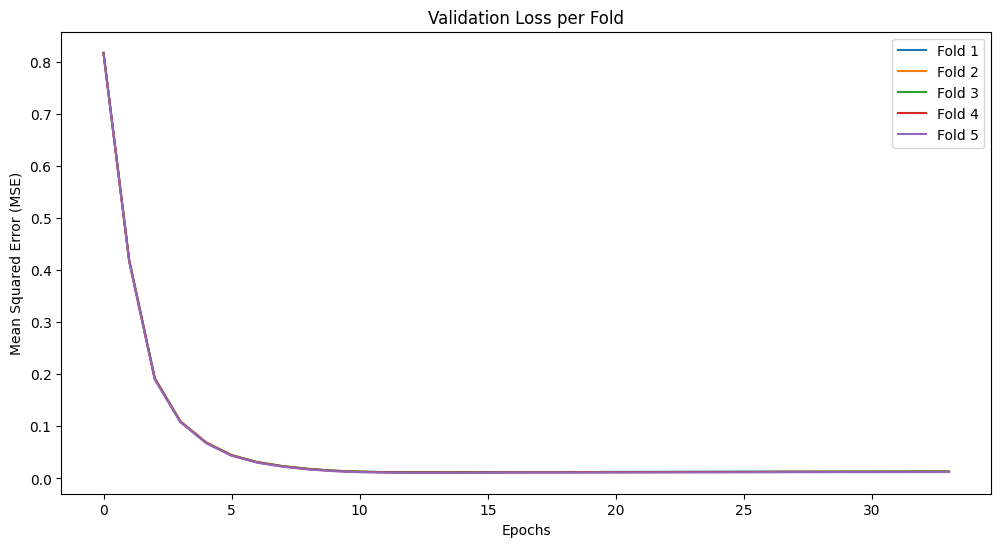

In [104]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [94]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 52


### Testing

In [95]:
# Test the model
model = generate_model()
model.fit(X_train, Y_train, epochs=final_epoch_number)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/52


2024-04-29 23:07:11.455514: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


87/87 [==============================] - 4s 42ms/step - loss: 4.1729
Epoch 2/52
87/87 [==============================] - 3s 33ms/step - loss: 1.7468
Epoch 3/52
87/87 [==============================] - 3s 35ms/step - loss: 1.2271
Epoch 4/52
87/87 [==============================] - 3s 33ms/step - loss: 0.9647
Epoch 5/52
87/87 [==============================] - 3s 32ms/step - loss: 0.7870
Epoch 6/52
87/87 [==============================] - 3s 34ms/step - loss: 0.6540
Epoch 7/52
87/87 [==============================] - 3s 31ms/step - loss: 0.5411
Epoch 8/52
87/87 [==============================] - 3s 37ms/step - loss: 0.4432
Epoch 9/52
87/87 [==============================] - 3s 35ms/step - loss: 0.3581
Epoch 10/52
87/87 [==============================] - 3s 39ms/step - loss: 0.2860
Epoch 11/52
87/87 [==============================] - 3s 36ms/step - loss: 0.2278
Epoch 12/52
87/87 [==============================] - 3s 33ms/step - loss: 0.1832
Epoch 13/52
87/87 [=============================

2024-04-29 23:09:46.330738: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


22/22 [==============================] - 1s 27ms/step - loss: 0.0107
Test MSE: 0.0107
Test RMSE: 0.1032


In [100]:
# As a baseline, calculate the RMSE of predicting only zeros
baseline_mse = np.mean(Y_test**2)
print(f"Baseline MSE: {baseline_mse:.4f}")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MSE: 0.0101
Baseline RMSE: 0.1004


### Training of final model

In [96]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=final_epoch_number)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/52


2024-04-29 23:09:49.775928: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


108/108 [==============================] - 7s 36ms/step - loss: 3.7359
Epoch 2/52
108/108 [==============================] - 4s 36ms/step - loss: 1.5021
Epoch 3/52
108/108 [==============================] - 4s 38ms/step - loss: 1.0500
Epoch 4/52
108/108 [==============================] - 4s 34ms/step - loss: 0.8125
Epoch 5/52
108/108 [==============================] - 4s 34ms/step - loss: 0.6473
Epoch 6/52
108/108 [==============================] - 4s 36ms/step - loss: 0.5128
Epoch 7/52
108/108 [==============================] - 4s 34ms/step - loss: 0.3989
Epoch 8/52
108/108 [==============================] - 4s 34ms/step - loss: 0.3040
Epoch 9/52
108/108 [==============================] - 4s 34ms/step - loss: 0.2297
Epoch 10/52
108/108 [==============================] - 4s 34ms/step - loss: 0.1758
Epoch 11/52
108/108 [==============================] - 4s 36ms/step - loss: 0.1388
Epoch 12/52
108/108 [==============================] - 4s 40ms/step - loss: 0.1130
Epoch 13/52
108/108 [===

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [97]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)

X_test_point shape: (1, 2712)
1/1 [==============================] - 0s 204ms/step
Test point prediction:
Actual: [[ 0.24646142  0.          0.         ...  0.01262706 -0.03002182
  -0.03236813]]
Predicted: [[ 0.05098654  0.04281274  0.04474949 ... -0.03886313 -0.04912224
  -0.04856855]]


2024-04-29 23:13:11.862086: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
